In [8]:
import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [9]:
resume_df = pd.read_csv(
    "../data/processed/cleaned_resume_dataset.csv"
)

print("Dataset Loaded Successfully")
print("Shape:", resume_df.shape)

resume_df.head()

Dataset Loaded Successfully
Shape: (10174, 7)


,Role,Resume,Decision,Reason_for_decision,Job_Description,Clean_Resume,Clean_Job_Description
0,E-commerce Specialist,Here's a professional resume for Jason Jones:\...,reject,Lacked leadership skills for a senior position.,Be part of a passionate team at the forefront ...,here professional resume jason jones jason jon...,part passionate team forefront machine learnin...
1,Game Developer,Here's a professional resume for Ann Marshall:...,select,Strong technical skills in AI and ML.,Help us build the next-generation products as ...,here professional resume ann marshall ann mars...,help u build nextgeneration product game devel...
2,Human Resources Specialist,Here's a professional resume for Patrick Mccla...,reject,Insufficient system design expertise for senio...,We need a Human Resources Specialist to enhanc...,here professional resume patrick mcclain patri...,need human resource specialist enhance team te...
3,E-commerce Specialist,Here's a professional resume for Patricia Gray...,select,Impressive leadership and communication abilit...,Be part of a passionate team at the forefront ...,here professional resume patricia gray patrici...,part passionate team forefront cloud computing...
4,E-commerce Specialist,Here's a professional resume for Amanda Gross:...,reject,Lacked leadership skills for a senior position.,We are looking for an experienced E-commerce S...,here professional resume amanda gross amanda g...,looking experienced ecommerce specialist join ...


In [2]:
rf_model = joblib.load(
    "../models/trained_models/random_forest.pkl"
)

print("Random Forest model loaded successfully.")

Random Forest model loaded successfully.


In [11]:
print(resume_df.columns)

Index(['Role', 'Resume', 'Decision', 'Reason_for_decision', 'Job_Description',
       'Clean_Resume', 'Clean_Job_Description'],
      dtype='str')


In [12]:
# Input feature
X = resume_df["Clean_Resume"]

# Target label
y = resume_df["Decision"].map({
    "reject": 0,
    "select": 1
})

print("Number of Samples :", len(X))
print("\nLabel Distribution:")
print(y.value_counts())

Number of Samples : 10174

Label Distribution:
Decision
0    5114
1    5060
Name: count, dtype: int64


In [13]:
import joblib

vectorizer = joblib.load("../models/tfidf_vectorizer.pkl")

print("TF-IDF Vectorizer loaded successfully.")

TF-IDF Vectorizer loaded successfully.


In [14]:
X_tfidf = vectorizer.transform(X)

print("TF-IDF Matrix Shape:", X_tfidf.shape)

TF-IDF Matrix Shape: (10174, 5000)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

Training Samples : 8139
Testing Samples  : 2035


In [16]:
import joblib

models = {
    "Logistic Regression": joblib.load("../models/trained_models/logistic_regression.pkl"),
    "Random Forest": joblib.load("../models/trained_models/random_forest.pkl"),
    "Linear SVM": joblib.load("../models/trained_models/linear_svm.pkl"),
    "Multinomial Naive Bayes": joblib.load("../models/trained_models/multinomial_naive_bayes.pkl"),
    "Dummy Classifier": joblib.load("../models/trained_models/dummy_classifier.pkl")
}

print("All trained models loaded successfully.")

All trained models loaded successfully.


In [19]:
evaluation_results = []

for model_name, model in models.items():

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions, zero_division=0)
    recall = recall_score(y_test, predictions, zero_division=0)
    f1 = f1_score(y_test, predictions, zero_division=0)

    evaluation_results.append({
        "Model": model_name,
        "Accuracy": round(accuracy, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1-Score": round(f1, 4)
    })

results_df = pd.DataFrame(evaluation_results)

results_df.sort_values(
    by="Accuracy",
    ascending=False,
    inplace=True
)

results_df.reset_index(drop=True, inplace=True)

results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.5808,0.5788,0.5771,0.5779
1,Logistic Regression,0.5799,0.5781,0.5741,0.5761
2,Linear SVM,0.5759,0.5730,0.5781,0.5755
3,Multinomial Naive Bayes,0.5705,0.5513,0.7332,0.6293
4,Dummy Classifier,0.5027,0.0000,0.0000,0.0000


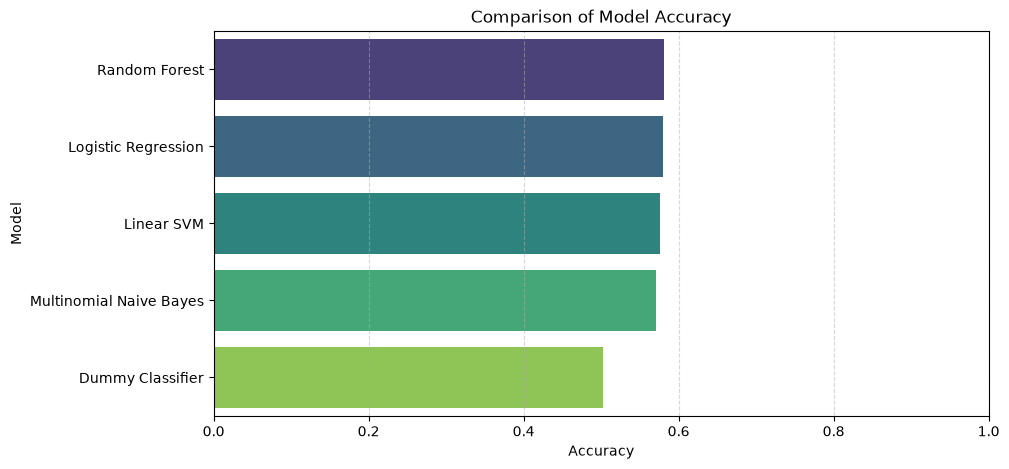

In [20]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model",
    hue="Model",
    palette="viridis",
    legend=False
)

plt.title("Comparison of Model Accuracy")
plt.xlabel("Accuracy")
plt.ylabel("Model")

plt.xlim(0, 1)
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.show()

In [21]:
best_model = models["Random Forest"]

predictions = best_model.predict(X_test)

print("Classification Report\n")

print(classification_report(
    y_test,
    predictions,
    target_names=["Reject", "Select"]
))

Classification Report

              precision    recall  f1-score   support

      Reject       0.58      0.58      0.58      1023
      Select       0.58      0.58      0.58      1012

    accuracy                           0.58      2035
   macro avg       0.58      0.58      0.58      2035
weighted avg       0.58      0.58      0.58      2035



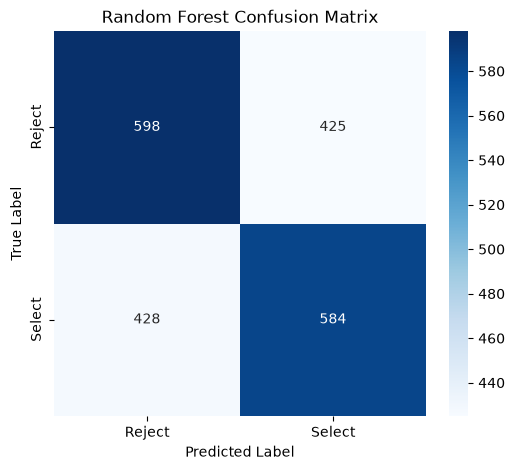

In [22]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Reject", "Select"],
    yticklabels=["Reject", "Select"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [23]:
print(hasattr(best_model, "predict_proba"))

True


AUC Score: 0.6444


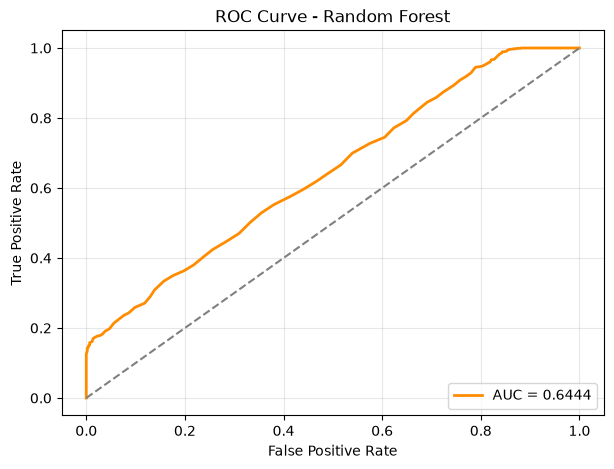

In [24]:
# Predict probabilities for the positive class
y_prob = best_model.predict_proba(X_test)[:, 1]

# Calculate ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC Score
auc_score = roc_auc_score(y_test, y_prob)

print(f"AUC Score: {auc_score:.4f}")

# Plot ROC Curve
plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, color="darkorange", linewidth=2,
         label=f"AUC = {auc_score:.4f}")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend(loc="lower right")

plt.grid(alpha=0.3)

plt.show()

In [25]:
cv_scores = cross_val_score(
    best_model,
    X_tfidf,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores:")
print(cv_scores)

print("\nAverage Accuracy:", round(cv_scores.mean(), 4))
print("Standard Deviation:", round(cv_scores.std(), 4))

Cross Validation Scores:
[0.51056511 0.52432432 0.51793612 0.49336609 0.61996067]

Average Accuracy: 0.5332
Standard Deviation: 0.0446


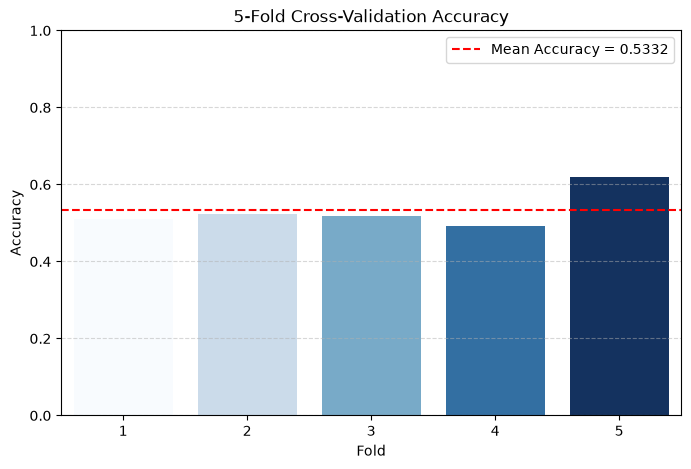

In [26]:
# Visualize Cross-Validation Scores

cv_df = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "Accuracy": cv_scores
})

plt.figure(figsize=(8, 5))

sns.barplot(
    data=cv_df,
    x="Fold",
    y="Accuracy",
    hue="Fold",
    palette="Blues",
    legend=False
)

plt.axhline(
    cv_scores.mean(),
    color="red",
    linestyle="--",
    label=f"Mean Accuracy = {cv_scores.mean():.4f}"
)

plt.title("5-Fold Cross-Validation Accuracy")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

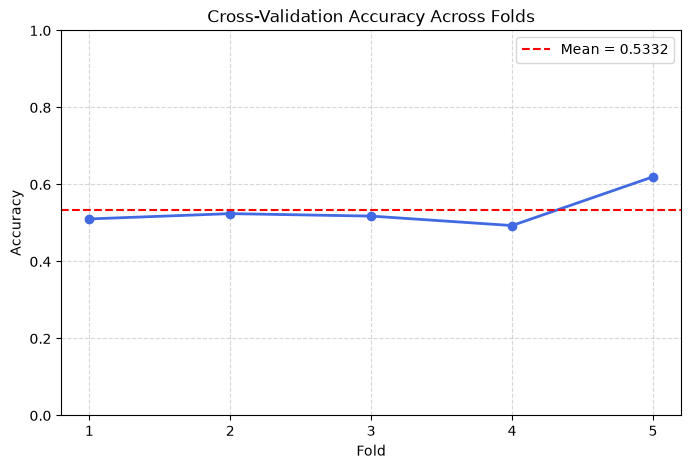

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 6),
    cv_scores,
    marker="o",
    linewidth=2,
    color="royalblue"
)

plt.axhline(
    cv_scores.mean(),
    color="red",
    linestyle="--",
    label=f"Mean = {cv_scores.mean():.4f}"
)

plt.xticks(range(1, 6))
plt.ylim(0, 1)

plt.title("Cross-Validation Accuracy Across Folds")
plt.xlabel("Fold")
plt.ylabel("Accuracy")

plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.show()

In [28]:
import os

os.makedirs("../results", exist_ok=True)

results_df.to_csv(
    "../results/model_evaluation_results.csv",
    index=False
)

print("Evaluation results saved successfully.")

Evaluation results saved successfully.


# **Summary**

## Objective

The objective of this notebook was to evaluate the performance of the trained machine learning models using multiple evaluation metrics.

## Evaluation Performed

The following evaluation techniques were applied:

- Accuracy
- Precision
- Recall
- F1-Score
- Classification Report
- Confusion Matrix
- ROC Curve and AUC Score
- 5-Fold Cross Validation

## Observations

- Random Forest achieved the highest overall accuracy (approximately 58%).
- Logistic Regression and Linear SVM showed comparable performance.
- Multinomial Naive Bayes achieved the highest recall and F1-score but lower precision.
- Dummy Classifier served as the baseline model and was outperformed by all trained models.
- Cross-validation indicated that the model performance was reasonably consistent across different folds, although some variation was observed.

## Conclusion

Based on the evaluation results, Random Forest was selected as the final model for the FairHire system because it achieved the best balance between accuracy, precision, and recall.